## modèle de prédiction de démission

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance


import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

## Chargement du dataset

In [5]:
DATA_PATH = "HRDataset_v14.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Structure des données

In [6]:
print("Shape du dataset :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

Shape du dataset : (311, 36)

Colonnes :
['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


## Nettoyage léger des colonnes texte

In [7]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

## Exploration des données

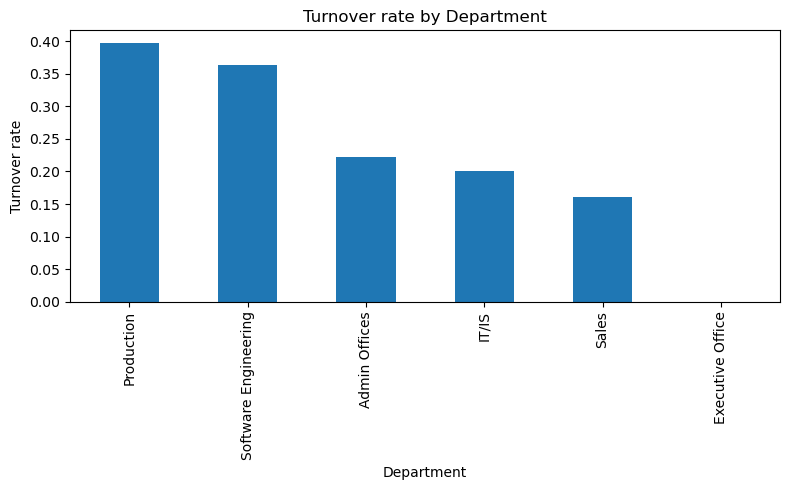

In [8]:
turnover_by_dept = df.groupby("Department")["Termd"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
turnover_by_dept.plot(kind="bar")

plt.title("Turnover rate by Department")
plt.ylabel("Turnover rate")
plt.xlabel("Department")

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

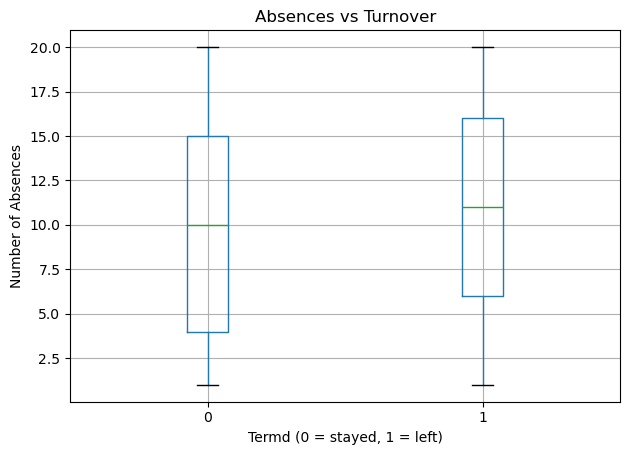

In [9]:
plt.figure(figsize=(7,5))

df.boxplot(column="Absences", by="Termd")

plt.title("Absences vs Turnover")
plt.suptitle("")
plt.xlabel("Termd (0 = stayed, 1 = left)")
plt.ylabel("Number of Absences")

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

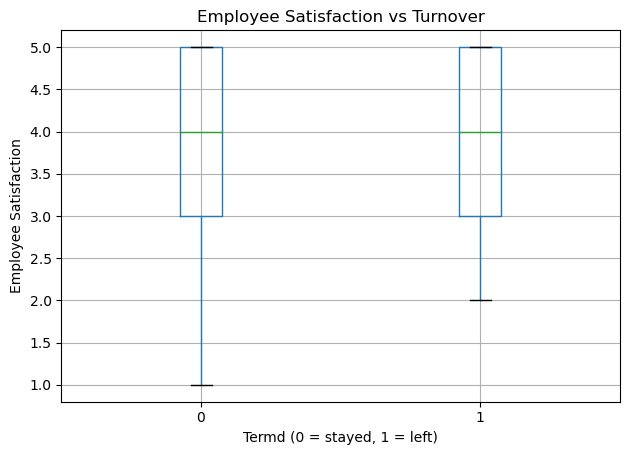

In [10]:
plt.figure(figsize=(7,5))

df.boxplot(column="EmpSatisfaction", by="Termd")

plt.title("Employee Satisfaction vs Turnover")
plt.suptitle("")
plt.xlabel("Termd (0 = stayed, 1 = left)")
plt.ylabel("Employee Satisfaction")

plt.tight_layout()
plt.show()

In [11]:


# On garde uniquement les variables numériques
num_df = df.select_dtypes(include=["int64", "float64"])

# Calcul de la corrélation
corr_matrix = num_df.corr()

# Création de la heatmap interactive
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Interactive Correlation Matrix"
)

fig.update_layout(
    width=900,
    height=800
)

fig.show()

In [12]:
import plotly.express as px

# calcul de la corrélation
corr_matrix = df.corr(numeric_only=True)

# corrélation avec la cible
corr_with_target = corr_matrix["Termd"].drop("Termd")

# tri par importance
corr_sorted = corr_with_target.sort_values(key=abs, ascending=False)

# on prend les 10 plus corrélées
top_features = corr_sorted.head(10)

fig = px.bar(
    x=top_features.values,
    y=top_features.index,
    orientation='h',
    title="Top Features Correlated with Employee Turnover (Termd)",
    labels={"x": "Correlation", "y": "Feature"},
    color=top_features.values,
    color_continuous_scale="Viridis"
)

fig.update_layout(height=500)

fig.show()

## Sélection de features avec ANOVA (F-Test) et Information Mutuelle

In [8]:
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [6]:
# Préparation des données pour la sélection de features
y = df['Termd']

# Exclure les colonnes non pertinentes (IDs et target)
exclude_cols = ['EmpID', 'Employee_Name', 'Termd']
X = df.drop(columns=exclude_cols)

# Séparer features numériques et catégorielles
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

print(f"Features numériques: {list(num_features)}")
print(f"Features catégorielles: {list(cat_features)}")

Features numériques: ['MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'PositionID', 'Zip', 'ManagerID', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences']
Features catégorielles: ['Position', 'State', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'RecruitmentSource', 'PerformanceScore', 'LastPerformanceReview_Date']


In [9]:
# ANOVA (F-Test) pour features numériques
from sklearn.feature_selection import SelectKBest

X_num = X[num_features].fillna(X[num_features].mean())  # Gérer les NaN

selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_num, y)

anova_scores = pd.Series(selector_anova.scores_, index=num_features).sort_values(ascending=False)

print("Scores ANOVA (F-Test) pour features numériques (triés par importance):")
print(anova_scores.head(10))  # Top 10

Scores ANOVA (F-Test) pour features numériques (triés par importance):
EmpStatusID               2744.770531
ManagerID                   13.934068
FromDiversityJobFairID       6.892888
SpecialProjectsCount         6.865443
PositionID                   6.828596
Zip                          6.088348
DaysLateLast30               5.856057
MaritalStatusID              3.081444
Absences                     3.013370
Salary                       2.754331
dtype: float64


In [10]:
# Information Mutuelle pour toutes les features (après encodage des catégorielles)
X_encoded = X.copy()

# Encoder les features catégorielles
for col in cat_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Gérer les NaN dans les numériques
X_encoded[num_features] = X_encoded[num_features].fillna(X_encoded[num_features].mean())

# Calculer l'information mutuelle
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)

mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

print("Scores Information Mutuelle (triés par importance):")
print(mi_series.head(10))  # Top 10

Scores Information Mutuelle (triés par importance):
EmploymentStatus              0.638865
TermReason                    0.624647
DateofTermination             0.610428
EmpStatusID                   0.607213
LastPerformanceReview_Date    0.394578
DateofHire                    0.175944
ManagerID                     0.115210
RecruitmentSource             0.089644
MaritalStatusID               0.059557
Position                      0.041006
dtype: float64


In [11]:
# Lister les colonnes importantes basées sur ANOVA et Information Mutuelle

# Top 10 features from ANOVA
top_anova = anova_scores.head(10)
print("Top 10 features from ANOVA (F-Test):")
print(top_anova)
print()

# Top 10 features from Mutual Information
top_mi = mi_series.head(10)
print("Top 10 features from Mutual Information:")
print(top_mi)
print()

# Colonnes importantes combinées (union des deux listes)
important_features = set(top_anova.index) | set(top_mi.index)
print("Colonnes importantes combinées (union ANOVA et MI):")
print(sorted(list(important_features)))
print(f"Nombre total de colonnes importantes: {len(important_features)}")

Top 10 features from ANOVA (F-Test):
EmpStatusID               2744.770531
ManagerID                   13.934068
FromDiversityJobFairID       6.892888
SpecialProjectsCount         6.865443
PositionID                   6.828596
Zip                          6.088348
DaysLateLast30               5.856057
MaritalStatusID              3.081444
Absences                     3.013370
Salary                       2.754331
dtype: float64

Top 10 features from Mutual Information:
EmploymentStatus              0.638865
TermReason                    0.624647
DateofTermination             0.610428
EmpStatusID                   0.607213
LastPerformanceReview_Date    0.394578
DateofHire                    0.175944
ManagerID                     0.115210
RecruitmentSource             0.089644
MaritalStatusID               0.059557
Position                      0.041006
dtype: float64

Colonnes importantes combinées (union ANOVA et MI):
['Absences', 'DateofHire', 'DateofTermination', 'DaysLateLast30', 'E

## Entraînement des modèles avec features sélectionnées

In [12]:
import xgboost as xgb

In [13]:
# Sélectionner les features importantes
X_selected = X[list(important_features)]

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Colonnes sélectionnées: {list(important_features)}")

Shape X_train: (248, 17), X_test: (63, 17)
Colonnes sélectionnées: ['LastPerformanceReview_Date', 'EmploymentStatus', 'Zip', 'DateofTermination', 'DaysLateLast30', 'ManagerID', 'RecruitmentSource', 'TermReason', 'Absences', 'SpecialProjectsCount', 'DateofHire', 'Position', 'FromDiversityJobFairID', 'EmpStatusID', 'MaritalStatusID', 'PositionID', 'Salary']


In [14]:
# Définir le préprocesseur pour les features sélectionnées
num_features_selected = [col for col in num_features if col in important_features]
cat_features_selected = [col for col in cat_features if col in important_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), num_features_selected),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features_selected)
    ]
)

In [15]:
# Modèle 1: Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print()

Logistic Regression Results:
Accuracy: 0.9841
Precision: 1.0000
Recall: 0.9524
F1-Score: 0.9756
ROC-AUC: 1.0000



In [16]:
# Modèle 2: Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print()

Random Forest Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000



In [17]:
# Modèle 3: XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_pred_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print()

XGBoost Results:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000



## Entraînement des modèles avec les features sélectionnées